# GRU

[인공지능 차세대 톱스타, 한국인 조경현 교수](https://brunch.co.kr/@hvnpoet/127)


<img src="https://d.pr/i/5xtgUb+" width="500"/>


**GRU(Gated Recurrent Unit)** 는 RNN의 변형 구조 중 하나로, **LSTM(Long Short-Term Memory)** 와 유사하지만 구조가 더 간단하다. GRU는 **게이트 구조**를 사용해 RNN의 **기울기 소멸 문제**를 해결하면서도, 연산량을 줄이고 효율적으로 학습할 수 있도록 설계되었다.(문제에 따라 LSTM보다 더 나은 경우도 있다.)


1. **단순화된 구조**
   - GRU는 LSTM에서 사용되는 **셀 상태(Cell State)** 와 **은닉 상태(Hidden State)** 를 하나로 통합하여 **은닉 상태(h)** 만 유지한다.
   - LSTM의 3가지 게이트(망각, 입력, 출력 게이트) 대신, GRU는 **업데이트 게이트(Update Gate)** 와 **리셋 게이트(Reset Gate)** 의 2가지 게이트만 사용한다.

2. **장단기 의존성 처리**
   - GRU는 중요한 정보는 기억하고, 불필요한 정보는 잊는 과정을 통해 장기 의존성과 단기 의존성을 모두 처리할 수 있다.

3. **연산 효율성**
   - 구조가 단순하기 때문에 LSTM보다 계산량이 적고, 학습 속도가 더 빠르다.

**GRU의 게이트 구조**

1. **리셋 게이트 (Reset Gate)**  
   - 과거 정보를 **얼마나 잊을지** 결정한다.
   - 이전 은닉 상태가 현재 입력에 얼마나 반영될지를 제어한다.  
   - 수식:  
$$
r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r)
$$

2. **은닉 상태 업데이트**  
   - 새로운 은닉 상태는 리셋 게이트를 적용한 이전 은닉 상태와 현재 입력 정보를 결합하여 생성된다.  
   - 수식:  
$$
\tilde{h}_t = \tanh(W_h \cdot [r_t \cdot h_{t-1}, x_t] + b_h)
$$

3. **업데이트 게이트 (Update Gate)**  
   - 정보의 **기억 여부**를 결정한다.
   - 이전 시점의 정보와 현재 입력 정보를 결합하여 다음 은닉 상태에 어떤 정보를 전달할지 제어한다.  
   - 수식:  
$$
z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)
$$



4. **최종 은닉 상태**  
   - 업데이트 게이트를 사용해 이전 은닉 상태와 새로운 은닉 상태를 조합하여 최종 은닉 상태를 계산한다.  
   - 수식:  
$$
h_t = (1 - z_t) \cdot h_{t-1} + z_t \cdot \tilde{h}_t
$$

**GRU와 LSTM의 차이점**

| **특징**            | **LSTM**                                          | **GRU**                                  |
|----------------------|--------------------------------------------------|------------------------------------------|
| **게이트 수**        | 3개 (입력, 망각, 출력 게이트)                    | 2개 (업데이트 게이트, 리셋 게이트)              |
| **상태**            | 셀 상태(Cell State), 은닉 상태(Hidden State)      | 은닉 상태(Hidden State)만 사용           |
| **구조의 복잡성**   | 복잡함                                           | 단순함                                   |
| **계산량**          | 상대적으로 많음                                  | 상대적으로 적음                          |
| **성능 차이**        | 복잡한 시퀀스 데이터에 강점                      | 빠르고 간단한 시퀀스 데이터에 적합        |



## GRU 구조 확인

In [1]:
import torch
import torch.nn as nn

batch_size = 2
seq_len = 3
input_size = 4
hidden_size = 5

x = torch.randn(batch_size, seq_len, input_size)
print('x.shape', x.shape)

gru = nn.GRU(input_size, hidden_size, batch_first=True)
output, hidden = gru(x)

print('output : ', output.shape)    # (batch_size, seq_len, hidden_size)
print('hidden : ', hidden.shape)    # (num_layer, batch_size, hidden_size)

x.shape torch.Size([2, 3, 4])
output :  torch.Size([2, 3, 5])
hidden :  torch.Size([1, 2, 5])


## IMDB 리뷰 감정 분석

In [2]:
# keras 제공 imdb 데이터 셋
from tensorflow.keras.datasets import imdb

# 자주 사용 되는 300개의 단어로 제한
vocab_size = 300

# 시퀀스 길이 제한
seq_len = 100

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_test = X_test[:10000]
y_test = y_test[:10000]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

c:\Users\Playdata\AppData\Local\miniforge3\envs\dl_nlp_env\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


(25000,) (25000,)
(10000,) (10000,)


In [3]:
# 문장 길이 맞추기
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train = pad_sequences(X_train, maxlen=seq_len, padding='post', truncating='post')
X_test = pad_sequences(X_test, maxlen=seq_len, padding='post', truncating='post')

## GRU 모델

In [4]:
# GRU 모델 생성
class GRUSentimenticNet(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.gru(x)
        output = self.fc(hidden[-1]) # (num_layer, batch_size, hidden_dim)
        return output

embedding_dim = 100
hidden_dim = 16
output_dim = 1

model = GRUSentimenticNet(vocab_size, embedding_dim, hidden_dim, output_dim)
model

GRUSentimenticNet(
  (embedding): Embedding(300, 100, padding_idx=0)
  (gru): GRU(100, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)

In [5]:
# 모델 파라미터 확인
total_params = 0
for name, param in model.named_parameters():
    # print(name, param)
    if param.requires_grad:                 # 미분 가능한 파라미터만 
        param_count = param.numel()         # 모든 가중치 개수
        total_params += param_count         
        print(f'{name:<20} {str(list(param.shape)):<30} {param_count}')

print(f'Total Trainable Parameters : {total_params}')

embedding.weight     [300, 100]                     30000
gru.weight_ih_l0     [48, 100]                      4800
gru.weight_hh_l0     [48, 16]                       768
gru.bias_ih_l0       [48]                           48
gru.bias_hh_l0       [48]                           48
fc.weight            [1, 16]                        16
fc.bias              [1]                            1
Total Trainable Parameters : 35681


## GRU 양방향 모델

In [6]:
# GRU 모델 생성
class GRUSentimenticNet(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.gru(x)
        
        # 양방향 은닉 상태 처리
        forward_pass = hidden[-2]
        backward_pass = hidden[-1]
        hidden_merged = torch.cat((forward_pass, backward_pass), dim=1)

        output = self.fc(hidden_merged)
        return output

embedding_dim = 100
hidden_dim = 16
output_dim = 1

model = GRUSentimenticNet(vocab_size, embedding_dim, hidden_dim, output_dim)
model

GRUSentimenticNet(
  (embedding): Embedding(300, 100, padding_idx=0)
  (gru): GRU(100, 16, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [7]:
# 모델 파라미터 확인
total_params = 0
for name, param in model.named_parameters():
    # print(name, param)
    if param.requires_grad:                 # 미분 가능한 파라미터만 
        param_count = param.numel()         # 모든 가중치 개수
        total_params += param_count         
        print(f'{name:<20} {str(list(param.shape)):<30} {param_count}')

print(f'Total Trainable Parameters : {total_params}')

embedding.weight     [300, 100]                     30000
gru.weight_ih_l0     [48, 100]                      4800
gru.weight_hh_l0     [48, 16]                       768
gru.bias_ih_l0       [48]                           48
gru.bias_hh_l0       [48]                           48
gru.weight_ih_l0_reverse [48, 100]                      4800
gru.weight_hh_l0_reverse [48, 16]                       768
gru.bias_ih_l0_reverse [48]                           48
gru.bias_hh_l0_reverse [48]                           48
fc.weight            [1, 32]                        32
fc.bias              [1]                            1
Total Trainable Parameters : 41361


In [8]:
# one-hot encoding 에서 Embedding 으로 변경하여 입력 데이터 재가공
X_train = torch.tensor(X_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([25000, 100]) torch.Size([25000, 1])
torch.Size([10000, 100]) torch.Size([10000, 1])


In [9]:
# 학습/검증/평가 데이터 준비
from torch.utils.data import random_split, DataLoader, TensorDataset

batch_size = 64
train_size = int(len(X_train) * 0.8)
val_size = len(X_train) - train_size

train_dataset, val_dataset = random_split(TensorDataset(X_train, y_train), [train_size, val_size])
test_dataset = TensorDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [10]:
from torch.optim import Adam

# 손실 함수
criterion = nn.BCEWithLogitsLoss()
# 옵티마이저
optimizer = Adam(model.parameters(), lr=0.0001)

epochs = 100

# 시각화를 위한 기록
train_losses, val_losses, train_accs, val_accs = [], [], [], []

# 조기 종료 관련
early_stopping_patience = 20
best_val_loss = float('inf')
early_stopping_counter = 0

for epoch in range(epochs):
    total_loss, correct, total = 0, 0, 0

    # 학습
    model.train()
    for inputs, labels in train_dataloader:
        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        # 배치 로그
        total_loss += loss.item()
        prob = torch.sigmoid(output)
        pred = (prob >= 0.5).float()
        correct += (pred == labels).sum().item()
        total += labels.size(0)
    
    # 에폭 로그
    train_loss = total_loss / len(train_dataloader)
    train_losses.append(train_loss)
    train_acc = correct / total
    train_accs.append(train_acc)

    # 검증
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for val_inputs, val_labels in val_dataloader:

            output = model(val_inputs)
            loss = criterion(output, val_labels)

            # 배치 로그
            val_loss += loss.item()
            prob = torch.sigmoid(output)
            pred = (prob >= 0.5).float()
            val_correct += (pred == val_labels).sum().item()
            val_total += val_labels.size(0)

    # 에폭 로그
    val_loss = val_loss / len(val_dataloader)
    val_losses.append(val_loss)
    val_acc = val_correct / val_total
    val_accs.append(val_acc)

    print(f'Epoch {epoch + 1}/{epochs}: Train Loss {train_loss:.4f} \
          Train Acc {train_acc:.4f} Val Loss {val_loss:.4f} Val Acc {val_acc:.4f}')
    
    # 조기종료
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= early_stopping_patience:
            print(f'Early stopped at Epoch {epoch + 1}')
            break

Epoch 1/100: Train Loss 0.6978           Train Acc 0.5048 Val Loss 0.6955 Val Acc 0.5118
Epoch 2/100: Train Loss 0.6932           Train Acc 0.5239 Val Loss 0.6923 Val Acc 0.5234
Epoch 3/100: Train Loss 0.6896           Train Acc 0.5384 Val Loss 0.6897 Val Acc 0.5374
Epoch 4/100: Train Loss 0.6862           Train Acc 0.5516 Val Loss 0.6871 Val Acc 0.5494
Epoch 5/100: Train Loss 0.6826           Train Acc 0.5633 Val Loss 0.6846 Val Acc 0.5532
Epoch 6/100: Train Loss 0.6789           Train Acc 0.5723 Val Loss 0.6817 Val Acc 0.5628
Epoch 7/100: Train Loss 0.6746           Train Acc 0.5837 Val Loss 0.6785 Val Acc 0.5642
Epoch 8/100: Train Loss 0.6694           Train Acc 0.5945 Val Loss 0.6742 Val Acc 0.5800
Epoch 9/100: Train Loss 0.6634           Train Acc 0.6052 Val Loss 0.6688 Val Acc 0.5908
Epoch 10/100: Train Loss 0.6561           Train Acc 0.6156 Val Loss 0.6633 Val Acc 0.5928
Epoch 11/100: Train Loss 0.6482           Train Acc 0.6268 Val Loss 0.6563 Val Acc 0.6092
Epoch 12/100: Train

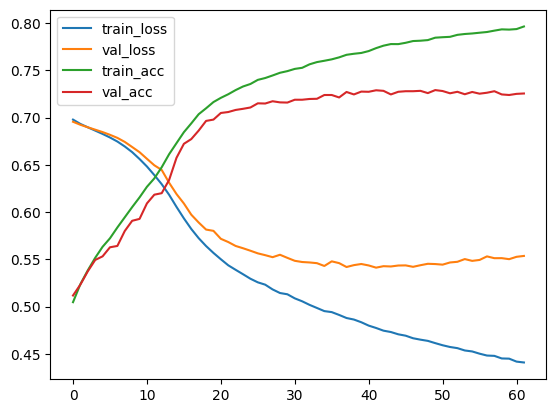

In [11]:
# 시각화
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'train_loss' : train_losses,
    'val_loss' : val_losses,
    'train_acc' : train_accs,
    'val_acc': val_accs
})

df.plot()
plt.show()

In [12]:
# 평가
def evaluate_model(model, test_dataloader, criterion):
    model.eval()
    test_loss, test_correct, test_total = 0, 0, 0

    with torch.no_grad():
        for test_inputs, test_labels in test_dataloader:
            output = model(test_inputs)
            loss = criterion(output, test_labels)

            test_loss += loss.item()
            prob = torch.sigmoid(output)
            pred = (prob >= 0.5).float()
            test_correct += (pred == test_labels).sum().item()
            test_total += test_labels.size(0)

    test_loss = test_loss / len(test_dataloader)
    test_acc = test_correct / test_total

    return test_loss, test_acc

test_dataset = TensorDataset(X_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

test_loss, test_acc = evaluate_model(model, test_dataloader, criterion)
print(f'Test Loss {test_loss} Test Acc {test_acc}')


Test Loss 0.5652092262438149 Test Acc 0.7186
